In [40]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram

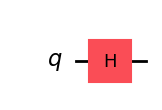

In [41]:

# Create a circuit with one qubit
circuit = QuantumCircuit(1)

# Add a Hadamard (H) gate on qubit 0, to create a superposition
circuit.h(0)

# Draw the circuit diagram. Delete "mpl" to get a text diagram.
circuit.draw("mpl")

In [42]:
# Now simulate the circuit by calculating the effect on state vectors.
# Set the initial state of the simulator to |0>
# The state vector has two coefficients, both 0
state = Statevector.from_int(0, 2)

# Apply the circuit to the state
state = state.evolve(circuit)

# Display using latex. This requires the pylatexenc module.
# Omit "latex" to get a numerical (not algebraic) view of the state vector.
state.draw("latex")

<IPython.core.display.Latex object>

In [43]:
# A different way of dislaying the state, again using latex
from qiskit.visualization import array_to_latex

array_to_latex(state)

<IPython.core.display.Latex object>

In [44]:
# The whole circuit is a unitary operator, which we can display.

U = Operator(circuit)
array_to_latex(U)

<IPython.core.display.Latex object>

In [45]:
# Or less beautifully:
U.data
# The format is a little bit odd. 0.j means the imaginary part is 0
# 0 is being displayed with a decimal point but no trailing 0
# j is used for the square root of -1, instead of i

array([[ 0.70710678+0.j,  0.70710678+0.j],
       [ 0.70710678+0.j, -0.70710678+0.j]])

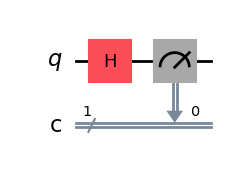

In [46]:
# Now reconstruct the circuit and add a measurement
# The second parameter of QuantumCircuit is the number of classical bits
circuit = QuantumCircuit(1,1)
circuit.h(0)

# The first list is the qubits to measure,
# the second list is the classical bits where the results go
circuit.measure([0],[0])
circuit.draw("mpl")

In [47]:
# We will need to transpile the circuit into QASM instructions for the back end

# Use BasicSimulator
backend = BasicSimulator()

# Compile / transpile
qc_compiled = transpile(circuit, backend)

# Run the circuit on the simulator.
# We've set the number of repeats of the circuit
# to be 1024, which is the default.
# The qubits start in state |0>
job_sim = backend.run(qc_compiled, shots=1024)

# Grab the results from the job (this doesn't produce any output).
result_sim = job_sim.result()

In [48]:
# The simplest way to see the results of the simulation
counts = result_sim.get_counts(qc_compiled)
print(counts)

# The results are not exactly half 0 and half 1, but should be close.
# There will be different results each time the previous cell is run.

{'1': 516, '0': 508}


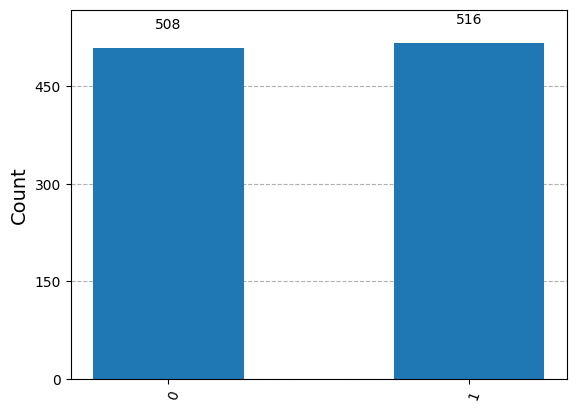

In [49]:
# We can also produce a graph

plot_histogram(counts)

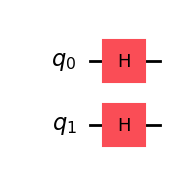

In [50]:
# Now let's move on to two qubits.
# Apply H to both qubits and see what we get.

circuit = QuantumCircuit(2)
circuit.h(0)
circuit.h(1)

circuit.draw("mpl")

In [51]:
state = Statevector.from_int(0, 4) # 4 is the number of basis states on 2 qubits
state = state.evolve(circuit)
state.draw("latex")

<IPython.core.display.Latex object>

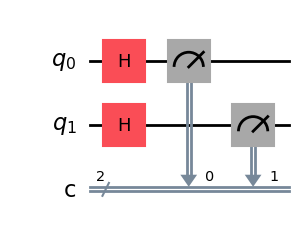

In [52]:
# Now measurement. This time we construct the measurement part
# of the circuit separately and then combine it with the first circuit.

# A new circuit with 2 qubits and 2 classical bits
meas = QuantumCircuit(2, 2)

# Map the quantum measurement to the classical bits
meas.measure(range(2), range(2))

# The Qiskit circuit object supports composition.
# Here the meas has to be first and front=True (putting it before)
# as compose must put a smaller circuit into a larger one.
qc = meas.compose(circuit, range(2), front=True)

qc.draw("mpl")

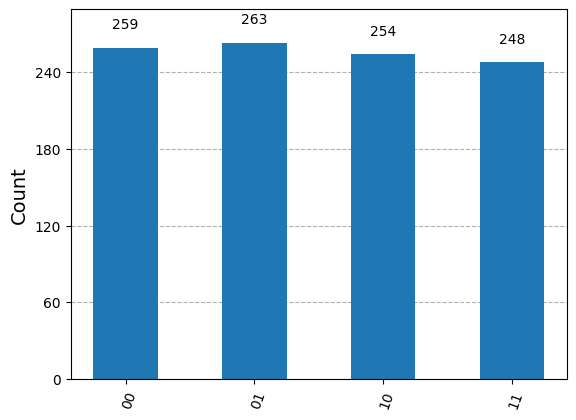

In [53]:
# Simulate again, using the same back end
qc_compiled = transpile(qc, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

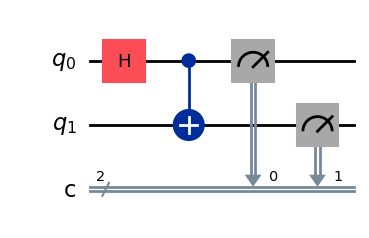

In [54]:
# Now for some entanglement.
# Construct a Bell state and measure both qubits to see that
# both measurements give the same result.

circuit = QuantumCircuit(2,2)
circuit.h(0)
circuit.cx(0,1) # cx means CNOT because it's a controlled version of x (negation)
circuit.measure(range(2),range(2))
circuit.draw("mpl")

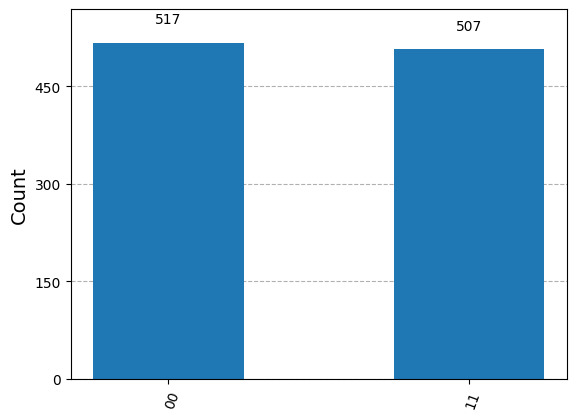

In [55]:
qc_compiled = transpile(circuit, backend)
job_sim = backend.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(qc_compiled)
plot_histogram(counts)

Phi+:


<IPython.core.display.Latex object>

Phi-:


<IPython.core.display.Latex object>

Psi+:


<IPython.core.display.Latex object>

Psi-:


<IPython.core.display.Latex object>

Phi+ counts: {'00': 480, '11': 544}


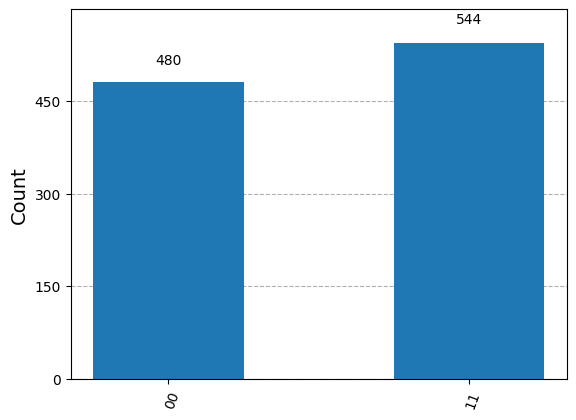

Phi- counts: {'00': 518, '11': 506}


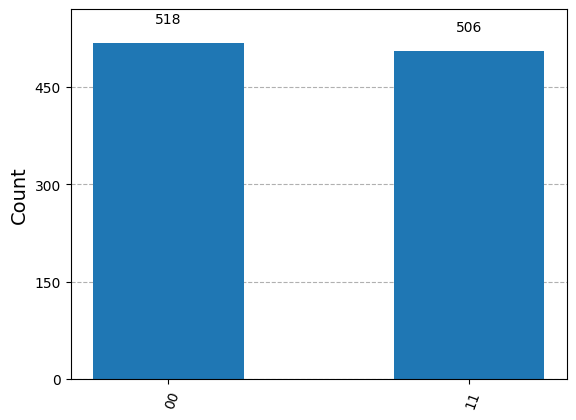

Psi+ counts: {'10': 499, '01': 525}


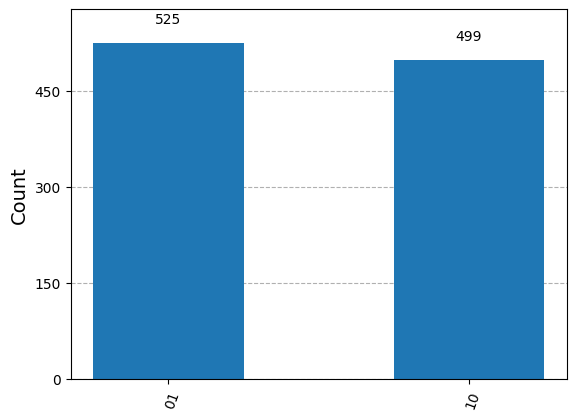

Psi- counts:


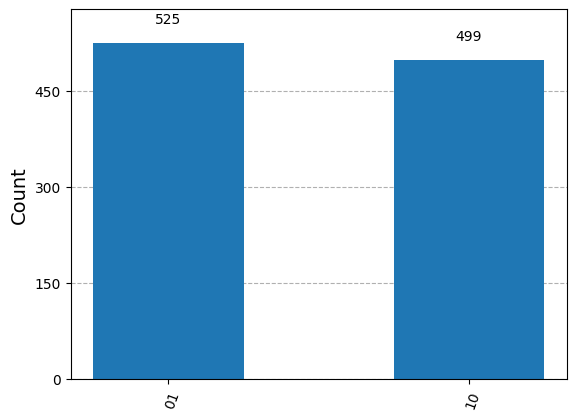

In [61]:
# EXERCISE 1

# Helper to simulate and plot
def simulate(circuit):
    qc_compiled = transpile(circuit, backend)
    job = backend.run(qc_compiled, shots=1024)
    counts = job.result().get_counts(qc_compiled)
    return counts

# Make a copy here of the circuit that creates the Bell state 1/sqrt(2) ( |00> + |11> ).
# Modify it to create the other Bell states: 1/sqrt(2) ( |00> - |11> ), 1/sqrt(2) ( |01> + |10> ), 1/sqrt(2) ( |01> - |10> ).

# State vector check [1/sqrt(2) ( |00> + |11> )]
circuit_phi_plus = QuantumCircuit(2)
circuit_phi_plus.h(0)
circuit_phi_plus.cx(0, 1)

state = Statevector.from_int(0, 4)
state = state.evolve(circuit_phi_plus)
print("Phi+:")
display(state.draw("latex"))

# State vector check [1/sqrt(2) ( |00> - |11> )]
circuit_phi_minus = QuantumCircuit(2)
circuit_phi_minus.h(0)
circuit_phi_minus.cx(0, 1)
circuit_phi_minus.z(0)    # Z gate flips the phase

state = Statevector.from_int(0, 4)
state = state.evolve(circuit_phi_minus)
print("Phi-:")
display(state.draw("latex"))

# State vector check [1/sqrt(2) ( |01> + |10> )]
circuit_psi_plus = QuantumCircuit(2)
circuit_psi_plus.h(0)
circuit_psi_plus.cx(0, 1)
circuit_psi_plus.x(1)    # X gate flips the target qubit

state = Statevector.from_int(0, 4)
state = state.evolve(circuit_psi_plus)
print("Psi+:")
display(state.draw("latex"))

# State vector check [1/sqrt(2) ( |01> - |10> )]
circuit_psi_minus = QuantumCircuit(2)
circuit_psi_minus.h(0)
circuit_psi_minus.cx(0, 1)
circuit_psi_minus.x(1)    # X gate flips the target qubit
circuit_psi_minus.z(0)    # Z gate flips the phase

state = Statevector.from_int(0, 4)
state = state.evolve(circuit_psi_minus)
print("Psi-:")
display(state.draw("latex"))


# You will need to use X and Z gates. Check that your circuit is correct by displaying the state vector in each case.
# Measurement [1/sqrt(2) ( |00> + |11> )]
circuit_phi_plus_meas = QuantumCircuit(2, 2)
circuit_phi_plus_meas.h(0)
circuit_phi_plus_meas.cx(0, 1)
circuit_phi_plus_meas.measure(range(2), range(2))

# Measurement [1/sqrt(2) ( |00> - |11> )]
circuit_phi_minus_meas = QuantumCircuit(2, 2)
circuit_phi_minus_meas.h(0)
circuit_phi_minus_meas.cx(0, 1)
circuit_phi_minus_meas.z(0)
circuit_phi_minus_meas.measure(range(2), range(2))

# Measurement [1/sqrt(2) ( |01> + |10> )]
circuit_psi_plus_meas = QuantumCircuit(2, 2)
circuit_psi_plus_meas.h(0)
circuit_psi_plus_meas.cx(0, 1)
circuit_psi_plus_meas.x(1)
circuit_psi_plus_meas.measure(range(2), range(2))

# Measurement [1/sqrt(2) ( |01> - |10> )]
circuit_psi_minus_meas = QuantumCircuit(2, 2)
circuit_psi_minus_meas.h(0)
circuit_psi_minus_meas.cx(0, 1)
circuit_psi_minus_meas.x(1)
circuit_psi_minus_meas.z(0)
circuit_psi_minus_meas.measure(range(2), range(2))


# For each of the Bell states, repeat the simulation with measurements and check that the results are as expected.
counts = simulate(circuit_phi_plus_meas)
print("Phi+ counts:", counts)
display(plot_histogram(counts))

counts = simulate(circuit_phi_minus_meas)
print("Phi- counts:", counts)
display(plot_histogram(counts))

counts = simulate(circuit_psi_plus_meas)
print("Psi+ counts:", counts)
display(plot_histogram(counts))

counts = simulate(circuit_psi_minus_meas)
print("Psi- counts:")
display(plot_histogram(counts))


--- GHZ state with n=2 qubits ---


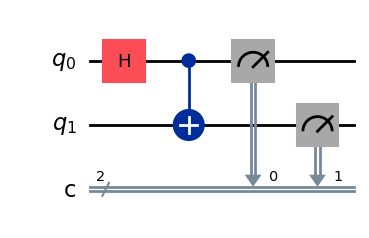

<IPython.core.display.Latex object>

Counts: {'11': 510, '00': 514}


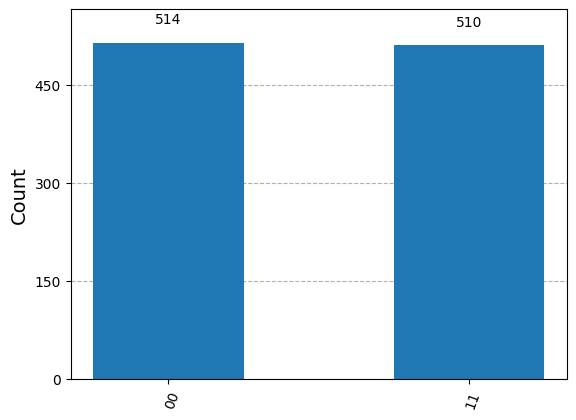


--- GHZ state with n=3 qubits ---


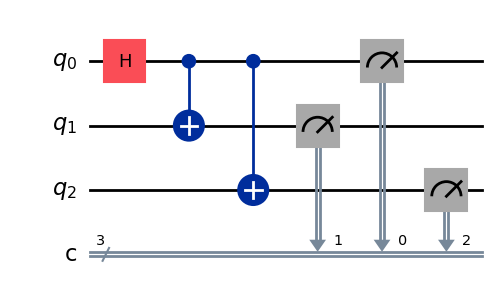

<IPython.core.display.Latex object>

Counts: {'000': 511, '111': 513}


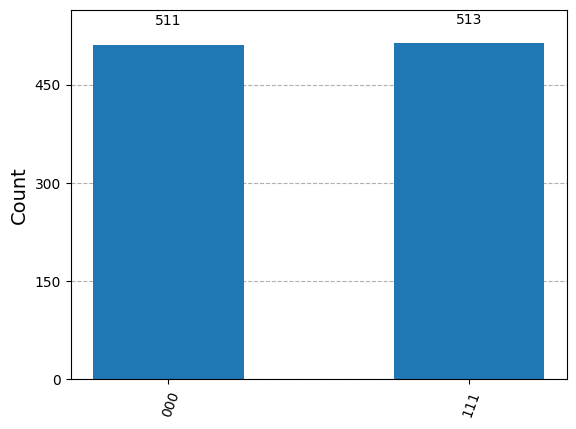


--- GHZ state with n=4 qubits ---


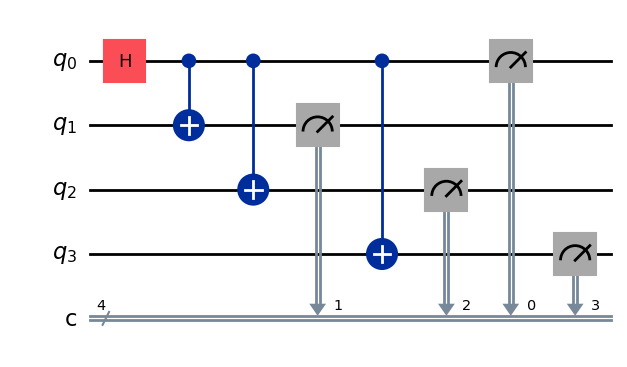

<IPython.core.display.Latex object>

Counts: {'0000': 499, '1111': 525}


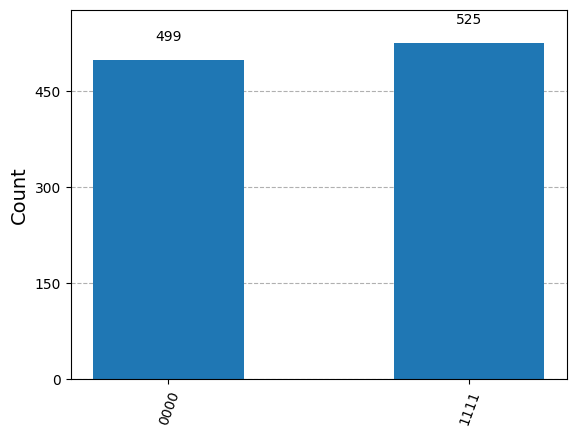


--- GHZ state with n=5 qubits ---


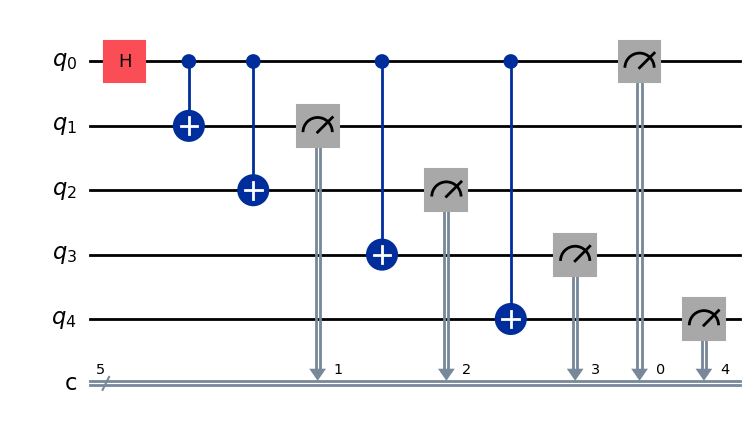

<IPython.core.display.Latex object>

Counts: {'00000': 495, '11111': 529}


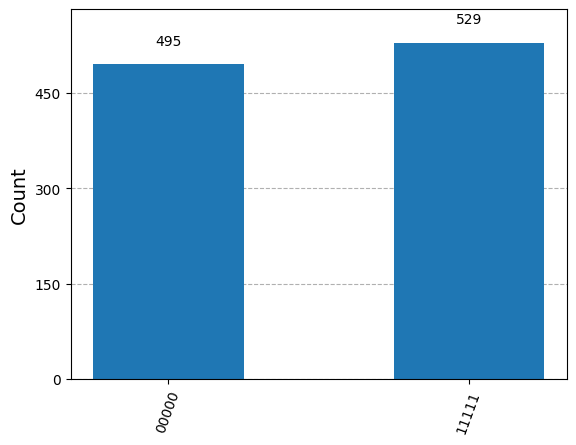


--- GHZ state with n=10 qubits ---


<IPython.core.display.Latex object>

Counts: {'0000000000': 515, '1111111111': 509}


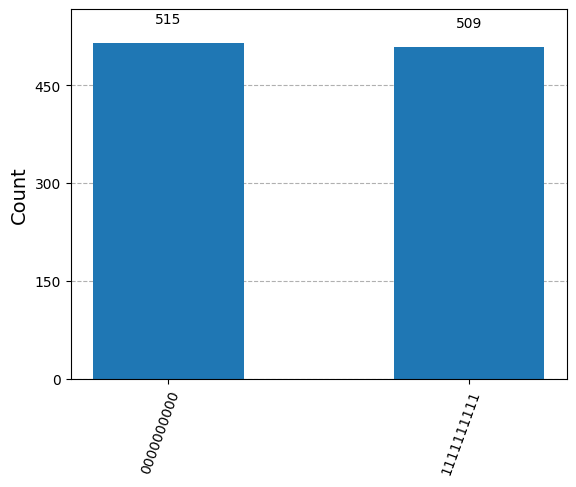


--- GHZ state with n=15 qubits ---
Counts: {'111111111111111': 511, '000000000000000': 513}

--- GHZ state with n=20 qubits ---
Counts: {'00000000000000000000': 540, '11111111111111111111': 484}


In [58]:
# EXERCISE 2

# The GHZ state on any number of qubits has the form  1/sqrt(2) ( |00...0> + |11...1> )
def make_ghz(n):
    """
    Constructs a GHZ state circuit for n qubits.
    Produces: 1/sqrt(2) ( |00...0> + |11...1> )
    """
    circuit = QuantumCircuit(n, n)
    circuit.h(0)                    # Put qubit 0 in superposition
    for i in range(1, n):
        circuit.cx(0, i)            # Entangle each qubit with qubit 0
    circuit.measure(range(n), range(n))
    return circuit

# The Bell state 1/sqrt(2) ( |00> + |11> ) is the case for two qubits.

# Write code to construct a circuit that produces a GHZ state for any given number of qubits.
# Try simulating the circuit, with measurements.

for n in [2, 3, 4, 5, 10, 15, 20]:
    print(f"\n--- GHZ state with n={n} qubits ---")

    circuit = make_ghz(n)

    # Draw circuit (only practical for small n)
    if n <= 5:
        display(circuit.draw("mpl"))

    # Verify state vector (only practical for small n, memory grows as 2^n)
    if n <= 10:
        circ_no_meas = QuantumCircuit(n)
        circ_no_meas.h(0)
        for i in range(1, n):
            circ_no_meas.cx(0, i)

        state = Statevector.from_int(0, 2**n)
        state = state.evolve(circ_no_meas)
        display(state.draw("latex"))

    # Simulate with measurements
    qc_compiled = transpile(circuit, backend)
    job = backend.run(qc_compiled, shots=1024)
    counts = job.result().get_counts(qc_compiled)
    print(f"Counts: {counts}")

    # Only plot histogram for small n (many qubits = many possible outcomes,
    # but GHZ only ever gives all-0s or all-1s so it's fine here)
    if n <= 10:
        display(plot_histogram(counts))

```
# How many qubits can the simulator handle in a reasonable time?
```

For general circuits, the statevector simulator scales as O(2ⁿ) in memory, making it impractical beyond roughly n = 25–30 qubits on a typical machine. However, for the GHZ state specifically, measurement simulation remains fast even at n = 20 (and beyond), because only two outcomes are possible regardless of qubit count. The n <= 10 guard on statevector verification reflects the memory constraint.